# Análise de nanotoxicidade em nanopartículas por algorítmo *k*-NN

**Disciplina:** Aprendizado de máquina

**Docente:** Daniel Roberto Cassar 

**Discente e autor:** Leonardo Ramos Gomes da Silva 

## Introdução

Este caderno demonstra a implementação do algorítmo de *k*-**vizinhos mais próximos** (*k*-NN) a fim de prever a nanotoxicidade de nanopartículas (NPs), baseado em diversos atributos. O banco de dados utilizado é o *"Nanoparticle Toxicity Dataset"*, disponibilizado pela plataforma Kaggle.

### Enunciado

**Objetivo:** Escolha um conjunto de dados que siga as considerações abaixo e estude o desempenho de modelos induzidos pelo algoritmo de *k* vizinhos mais próximos neste conjunto de dados considerando diferentes conjuntos de hiperparâmetros (pelo menos 10 conjuntos de hiperparâmetros diferentes). A entrega deve ser realizada em um notebook de Jupyter. A sugestão é que esta seja uma entrega com texto direto, sem a necessidade de longos parágrafos. É necessário utilizar o scikit‑learn para induzir os modelos de *k* vizinhos mais próximos. Não se esqueça de justificar a métrica de desempenho escolhida.
Considerações: O conjunto de dados deve ter as seguintes características:


* Pelo menos 5 atributos. Destes atributos, pelo menos um deles deve ser categórico
* Pelo menos 1 target (não há necessidade de mais que 1 target e pode ser um target categórico ou numérico, a sua escolha)
* Pelo menos 150 exemplos
* Os dados não podem ser sintéticos


**Expectativas:** É esperado que o trabalho siga as boas práticas apresentadas na disciplina, apresente resultados de forma gráfica, use seções bem nomeadas e bem divididas no notebook de Jupyter e encerre a entrega com uma seção chamada “Conclusões e principais aprendizados”. O trabalho deve ter uma seção chamada “Descrição do uso de IA neste trabalho” detalhando como foi a interação com ferramentas de IA para a construção dos textos e códigos.

**Pontuação base:** 7 (válida apenas caso o objetivo tenha sido realizado)


**Descontos usuais da pontuação base:**
* Alguma expectativa não foi atingida
* Trabalho não seguiu boas práticas apresentadas na disciplina. Lembre‑se de revisar o material 
apresentado e suas anotações durante a aula
* Trabalho não apresentou resultados de forma gráfica
* Não guiou o leitor na entrega
* Não interpretou e discutiu os resultados
* Gráfico sem legenda em um ou mais eixos
* Código que acusa erro ao rodar na ordem de cima para baixo
* Entrega sem referências
* Uso incorreto ou omisso de citações (incluindo falta de citação sobre uso de IA)
* Não soube explicar sobre estratégias e códigos utilizados na entrega
* Respostas incorretas às perguntas realizadas pelo professor durante o momento avaliativo
* Respostas incorretas às perguntas realizadas pelo Perguntador 2000™ durante o momento 
avaliativo
* Atraso na entrega do trabalho no Teams


**Pontuação complementar:** 3 (cada item abaixo pode valer até no máximo 1 ponto)
* Realizou uma boa análise exploratória dos dados e comparou o desempenho dos modelos com 
relação a um modelo baseline
* Checou como o desempenho dos modelos varia utilizando ou não utilizando dados normalizados de diferentes maneiras
* Checou o desempenho dos modelos variando o número de vizinhos
* Checou o desempenho dos modelos variando a função de distância (considerando pelo menos 
3 funções diferentes)
* Checou o desempenho dos modelos variando a estratégia de codificação do(s) atributo(s) categórico(s)


**Motivação e aprendizado:** Esta é uma tarefa introdutória da disciplina, sendo assim, a motivação 
principal é justamente iniciar sua jornada no campo do Aprendizado de Máquina.


**Sugestão de uso de IA nesta tarefa:** Um bom uso de IA pode ser para encontrar conjuntos 
de dados de seu interesse. Fora isso, debater com a IA sobre quais atividades complementares fazer, 
ponderando aprendizado e interesse, também é uma boa estratégia.


**Lembretes:**
* “Guiar o leitor” não é sinônimo de “escrever um livro”. É perfeitamente possível guiar o leitor 
com textos curtos e diretos. Um texto que guia o leitor é aquele que deixa claro o que será 
realizado antes de realizar a tarefa e depois discute o que foi observado.
* Citações devem aparecer o mais próximo possível do local onde a informação foi apresentada 
ao leitor. Ter apenas uma seção de referências sem as devidas citações no texto não é a maneira 
correta de redigir um texto científico e implicará em descontos na pontuação.


**Lore:** O Cubo Gelatinoso é uma criatura lendária muito perigosa que habita a Catacumba da 
Escuridão Sombria. Ele se aproveita dos corredores mal iluminados e da pressa que os aventureiros 
tem em sair da Catacumba para capturar suas presas. Com sorte você encontra algum Patrulheiro 
Formidável na região que possa te ajudar.

## Metodologia

#### Tratamento e rápida análise
O banco de dados será então introduzido e tratado. O método `df.dropna`, do módulo `pandas`, é utilizado para garantitr que não tenham exemplos com dados indisponíveis para a análise.

In [305]:
import pandas as pd

df = pd.read_csv("nanotox_dataset.csv")

ATRIBUTOS = ["NPs", "coresize", "hydrosize", "surfcharge", "surfarea", "Ec",
       "Expotime", "dosage"]
TARGET = ["class"]

x = df.reindex(ATRIBUTOS, axis=1)
y = df.reindex(TARGET, axis=1)

df = df.reindex(ATRIBUTOS + TARGET, axis=1)
df = df.dropna()

Vejamos os atributos.

In [306]:
x

,NPs,coresize,hydrosize,surfcharge,surfarea,Ec,Expotime,dosage
0,Al2O3,39.7,267.0,36.3,64.7,-1.51,24,0.001
1,Al2O3,39.7,267.0,36.3,64.7,-1.51,24,0.010
2,Al2O3,39.7,267.0,36.3,64.7,-1.51,24,0.100
3,Al2O3,39.7,267.0,36.3,64.7,-1.51,24,1.000
4,Al2O3,39.7,267.0,36.3,64.7,-1.51,24,5.000
...,...,...,...,...,...,...,...,...
876,ZnO,45.3,310.0,32.7,21.3,-3.89,24,20.000
877,ZnO,32.0,1093.0,21.6,37.0,-3.89,24,25.000
878,ZnO,46.3,239.0,42.8,24.1,-5.17,12,100.000
879,ZnO,35.6,295.5,-41.6,27.9,-3.89,24,10.000


Vejamos o target.

In [307]:
y

,class
0,nonToxic
1,nonToxic
2,nonToxic
3,nonToxic
4,nonToxic
...,...
876,Toxic
877,Toxic
878,Toxic
879,Toxic


Utilizando o método `describe()` para analisar a diferença média geral entre nanopartículas tóxicas e não tóxicas.

In [308]:
#Describe em partículas não tóxicas
logica = df["class"] == "nonToxic"

df.loc[logica].describe()

,coresize,hydrosize,surfcharge,surfarea,Ec,Expotime,dosage
count,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000,405.000000
mean,47.966667,522.805185,-4.405432,61.107654,-3.997210,21.977778,31.803132
std,31.236046,411.580450,22.644049,60.172709,0.611865,18.077172,46.244915
min,7.500000,74.000000,-41.600000,7.000000,-5.170000,3.000000,0.000010
25%,25.000000,267.000000,-11.700000,20.000000,-4.160000,6.000000,1.000000
50%,35.600000,310.000000,-10.700000,40.000000,-4.160000,24.000000,10.000000
75%,60.000000,687.000000,-2.400000,66.000000,-3.890000,24.000000,40.000000
max,125.000000,1843.000000,42.800000,210.000000,-1.510000,72.000000,300.000000


In [309]:
#Describe em partículas tóxicas
logica = df["class"] == "nonToxic"

df.loc[~logica].describe()

,coresize,hydrosize,surfcharge,surfarea,Ec,Expotime,dosage
count,476.000000,476.000000,476.000000,476.000000,476.000000,476.000000,476.000000
mean,63.414916,506.103571,6.787605,25.879538,-4.035924,32.123950,46.328782
std,34.121298,279.919506,26.901897,21.463784,0.402980,19.534783,27.966269
min,7.500000,236.000000,-41.600000,7.000000,-5.170000,3.000000,10.000000
25%,35.600000,273.400000,-11.700000,14.500000,-3.890000,24.000000,25.000000
50%,52.000000,360.000000,-2.400000,20.000000,-3.890000,24.000000,50.000000
75%,100.000000,687.000000,29.400000,27.900000,-3.890000,48.000000,50.000000
max,125.000000,1093.000000,42.800000,90.000000,-3.890000,72.000000,100.000000


Em primeiro, percebe-se que há mais exemplos de nanopartículas tóxicas, o que pode afetar, mesmo que minimamente, os dados. Pode-se perceber, pelas médias e medianas, que, em nanopartículas tóxicas, o tamanho do núcleo tende a ser maior e o tamanho hidrodinâmico menor - ou seja, o intervalo entre esses tamanhos diminui. Além disso, a área de superfície tende a ser menor, o que está associado com uma maior carga de superfície, visível nos dados. Além disso, os atributos de tempo de exposição e dosagem tendem a ser maiores em nanopartículas tóxicas.

In [310]:
logica1 = df["surfcharge"] == 42.8
logica2 = df["surfarea"] == 24.1

logica3 = df["NPs"] == "CuO"
logica4 = df["Ec"] == -5.17

logica = logica4 & logica3

df.loc[logica]

,NPs,coresize,hydrosize,surfcharge,surfarea,Ec,Expotime,dosage,class
18,CuO,46.3,239.0,42.8,24.1,-5.17,24,0.001,nonToxic
19,CuO,46.3,239.0,42.8,24.1,-5.17,24,0.010,nonToxic
20,CuO,46.3,239.0,42.8,24.1,-5.17,24,0.100,nonToxic
21,CuO,46.3,239.0,42.8,24.1,-5.17,24,1.000,nonToxic
22,CuO,46.3,239.0,42.8,24.1,-5.17,24,5.000,nonToxic
23,CuO,46.3,239.0,42.8,24.1,-5.17,24,10.000,Toxic
24,CuO,46.3,239.0,42.8,24.1,-5.17,24,20.000,Toxic
25,CuO,46.3,239.0,42.8,24.1,-5.17,24,50.000,Toxic
26,CuO,46.3,239.0,42.8,24.1,-5.17,24,100.000,Toxic
27,CuO,46.3,239.0,42.8,24.1,-5.17,12,0.001,nonToxic


##### Gráficos 
Os gráficos abaixo mostram cada característica isoladamente para cada tipo de nanopartícula para rápida análise de possíveis correlações.

Alumínio

#### Modelo Baseline

Antes de treinar o algorítmo o atributo `NPs` será convertido em número, utilizando a técnica do One Hot Encoder [1].

In [311]:
from sklearn.preprocessing import OneHotEncoder

encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
encoder.set_output(transform="pandas")

encoded_df = encoder.fit_transform(df[['NPs']])

# 3. Combine with original data if you have other columns, and drop old column
df = pd.concat([df, encoded_df], axis=1).drop(columns=['NPs'])

df.columns

Index(['coresize', 'hydrosize', 'surfcharge', 'surfarea', 'Ec', 'Expotime',
       'dosage', 'class', 'NPs_Al2O3', 'NPs_CuO', 'NPs_Fe2O3', 'NPs_TiO2',
       'NPs_ZnO'],
      dtype='str')

Atualizando os atributos utilizados na análise *k*-NN agora que o dado categórico foi convertido em binário para possibilitar a análise de aprendizado de máquina.

In [312]:
ATRIBUTOS = ["NPs_Al2O3", "NPs_CuO", "NPs_Fe2O3", "NPs_TiO2",
       "NPs_ZnO", "coresize", "hydrosize", "surfcharge", "surfarea", "Ec",
       "Expotime", "dosage"]

Importando a biblioteca *scikit-learn* com o método `train_test_split` a fim de realizar o treinamento do modelo para o algorítmo de *k* vizinhos-próximos. A `SEMENTE_ALEATORIA` foi decidida arbitrariamente pelo autor a fim de criar reprodutibilidade nos dados.

O tamanho do teste foi escolhido com 10% pois o arquivo tem bastante exemplos, o que gera uma boa parcela de teste e um grande número de dados restantes para treinar o algorítmo.

In [313]:
from sklearn.model_selection import train_test_split

TAMANHO_TESTE = 0.1
SEMENTE_ALEATORIA = 73701

indices = df.index

indices_treino, indices_teste = train_test_split(
    indices, test_size=TAMANHO_TESTE, random_state=SEMENTE_ALEATORIA,stratify=df[TARGET]
)

df_treino = df.loc[indices_treino]
df_teste = df.loc[indices_teste]

x_treino = df_treino[ATRIBUTOS]
y_treino = df_treino[TARGET]

x_teste = df_teste[ATRIBUTOS]
y_teste = df_teste[TARGET]

In [314]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

x_treino_padronizado = scaler.fit_transform(
    x_treino
)

x_teste_padronizado = scaler.transform(
    x_teste
)

A fim de classificar de forma binária deve haver uma ordem específica.

In [315]:
ordem_labels = df["class"].unique().tolist()

ordem_labels

['nonToxic', 'Toxic']

#### Modelo Baseline

O método `DummyClassifier` criará um modelo de *baseline* para analisar mais a frente a eficiência do modelo mais complexo.

In [316]:
from sklearn.dummy import DummyClassifier

modelo_baseline = DummyClassifier()
modelo_baseline.fit(x_treino, y_treino)

,"strategy strategy: {""most_frequent"", ""prior"", ""stratified"", ""uniform"", ""constant""}, default=""prior""Strategy to use to generate predictions.* ""most_frequent"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit`. The `predict_proba` method returns the matching one-hot encoded vector.* ""prior"": the `predict` method always returns the most frequent class label in the observed `y` argument passed to `fit` (like ""most_frequent""). ``predict_proba`` always returns the empirical class distribution of `y` also known as the empirical class prior distribution.* ""stratified"": the `predict_proba` method randomly samples one-hot vectors from a multinomial distribution parametrized by the empirical class prior probabilities. The `predict` method returns the class label which got probability one in the one-hot vector of `predict_proba`. Each sampled row of both methods is therefore independent and identically distributed.* ""uniform"": generates predictions uniformly at random from the list of unique classes observed in `y`, i.e. each class has equal probability.* ""constant"": always predicts a constant label that is provided by the user. This is useful for metrics that evaluate a non-majority class. .. versionchanged:: 0.24 The default value of `strategy` has changed to ""prior"" in version 0.24.",'prior'
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness to generate the predictions when``strategy='stratified'`` or ``strategy='uniform'``.Pass an int for reproducible output across multiple function calls.See :term:`Glossary <random_state>`.",None
,"constant constant: int or str or array-like of shape (n_outputs,), default=NoneThe explicit constant as predicted by the ""constant"" strategy. Thisparameter is useful only for the ""constant"" strategy.",None
Name,Type,Value
"class_prior_ class_prior_: ndarray of shape (n_classes,) or list of such arraysFrequency of each class observed in `y`. For multioutput classificationproblems, this is computed independently for each output.","ndarray[float64](2,)","[0.54,0.46]"
"classes_ classes_: ndarray of shape (n_classes,) or list of such arraysUnique class labels observed in `y`. For multi-output classificationproblems, this attribute is a list of arrays as each output has anindependent set of possible classes.","ndarray[object](2,)","['Toxic','nonToxic']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X` hasfeature names that are all strings.","ndarray[object](12,)","['NPs_Al2O3','NPs_CuO','NPs_Fe2O3',...,'Ec','Expotime','dosage']"
n_classes_ n_classes_: int or list of intNumber of label for each output.,int,2
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`.,int,12
n_outputs_ n_outputs_: intNumber of outputs.,int,1
sparse_output_ sparse_output_: boolTrue if the array returned from predict is to be in sparse CSC format.Is automatically set to True if the input `y` is passed in sparseformat.,bool,False


In [317]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

y_verdadeiro = y_teste
y_previsao = modelo_baseline.predict(x_teste)

matriz_conf = confusion_matrix(y_verdadeiro, y_previsao, labels=ordem_labels)
df_conf_baseline = pd.DataFrame(matriz_conf, ordem_labels, ordem_labels)

Criando uma matriz de confusão com as bibliotecas *scikit-learn* e *seaborn* para visualizar a acurácia, dada pela fórmula

$$
\mathrm{ACC = \frac{VP + VN}{VP + FP + VN + FN}}
$$

que mede a fração de quantos elementos foram corretamente classificado.

In [318]:
from sklearn.metrics import accuracy_score

acuracia_baseline = accuracy_score(y_verdadeiro, y_previsao)

Pode-se perceber que o modelo baseline classificou todos os elementos de acordo com a moda, ou seja: tóxicos, acertando apenas 53.93%. A acurácia, então, motiva a utilizar um modelo mais complexo para tentar prever.

O modelo utilizado, no caso, será o *k*-nn.

In [319]:
from sklearn.neighbors import KNeighborsClassifier

NUM_VIZINHOS = 3

modelo_knn = KNeighborsClassifier(NUM_VIZINHOS)
modelo_knn.fit(x_treino, y_treino)

C:\Users\leonardo2610065\AppData\Roaming\Python\Python313\site-packages\sklearn\neighbors\_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",3
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[object](2,)","['Toxic','nonToxic']"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


Isso daí de baixo é pra ver quais são a melhor parâmetro

In [320]:
y_verdadeiro = y_teste
y_previsao = modelo_knn.predict(x_teste)

matriz_conf = confusion_matrix(y_verdadeiro, y_previsao, labels=ordem_labels)
df_conf_knn = pd.DataFrame(matriz_conf, ordem_labels, ordem_labels)

In [321]:
acuracia_knn = accuracy_score(y_verdadeiro, y_previsao)

In [322]:
from sklearn.linear_model import LogisticRegression

modelo_rlog = LogisticRegression(max_iter=1000)
modelo_rlog.fit(x_treino, y_treino)

C:\Users\leonardo2610065\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


C:\Users\leonardo2610065\AppData\Roaming\Python\Python313\site-packages\sklearn\linear_model\_logistic.py:599: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [323]:
y_verdadeiro = y_teste
y_previsao = modelo_rlog.predict(x_teste)

matriz_conf = confusion_matrix(y_verdadeiro, y_previsao, labels=ordem_labels)
df_conf_regressor = pd.DataFrame(matriz_conf, ordem_labels, ordem_labels)

In [324]:
acuracia_regressor = accuracy_score(y_verdadeiro, y_previsao)

## Resultados e Discussão

O resultado de acurácia do modelo Baseline pode ser visualizada no gráfico 1.

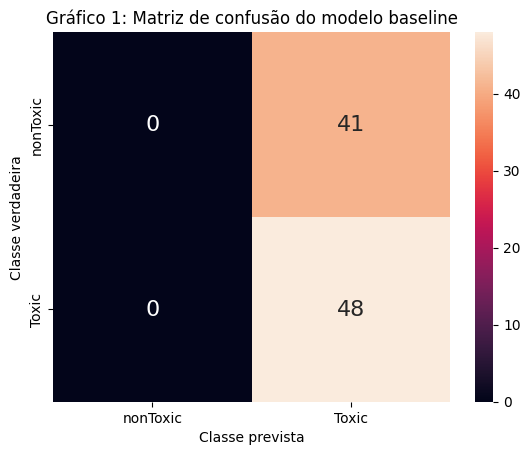

In [325]:
import matplotlib.pyplot as plt

sns.heatmap(df_conf_baseline, annot=True, annot_kws={"size": 16})

plt.title("Gráfico 1: Matriz de confusão do modelo baseline")
plt.xlabel("Classe prevista")
plt.ylabel("Classe verdadeira")
plt.show()

A acurácia do modelo Baseline pode ser vista abaixo:

In [326]:
print(f"Acurácia do modelo Baseline = {(acuracia_baseline*100):.2f}%")

Acurácia do modelo Baseline = 53.93%


Ao criar o modelo Baseline, este utiliza, com dados categóricos de classificação binária, a moda de todos os dados a fim de fazer a previsão, ou seja, é um modelo muito incerto. Pode-se perceber que a alta incerteza do modelo se deu pois não há discrepância entre a quantidade de tóxicos e não tóxicos. A acurácia do Baseline de apenas 53.93% nos incentiva, portanto, a procurar melhores modelos para classificação.

O resultado de acurácia do modelo *k*-NN pode ser visualizada no gráfico 2.

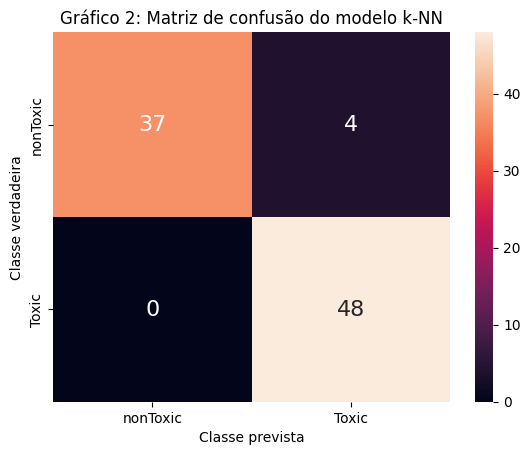

In [327]:
sns.heatmap(df_conf_knn, annot=True, annot_kws={"size": 16})

plt.title("Gráfico 2: Matriz de confusão do modelo k-NN")
plt.xlabel("Classe prevista")
plt.ylabel("Classe verdadeira")
plt.show()

In [328]:
print(f"Acurácia do modelo k-NN = {(acuracia_knn*100):.2f}%")

Acurácia do modelo k-NN = 95.51%


Com o modelo *k*-NN houve um aumento exorbitante na acurácia quando comparado ao Baseline, de aproximadamente 42%. É interessante notar que não houveram falsos positivos, ou seja, previsão de NPs tóxicas como não tóxicas. Neste caso, a classificação de NPs tóxicas como não tóxicas (falso positivo, FP) é mais perigoso que partículas não tóxicas como tóxicas (falso negativo, FN). Isso ocorre pois um falso negativo apenas requer dispêndio desnecessário de cuidado ao manipular, enquanto um falso positivo pode gerar descuido ao manipular soluções perigosas.

O resultado de acurácia do modelo *k*-NN com Regressão Logística pode ser visualizada no gráfico 3.

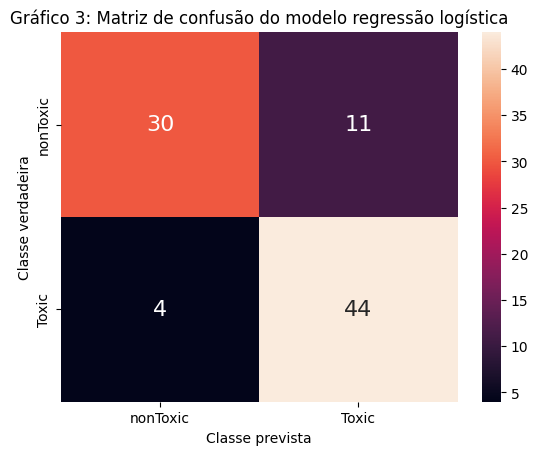

In [329]:
sns.heatmap(df_conf_regressor, annot=True, annot_kws={"size": 16})

plt.title("Gráfico 3: Matriz de confusão do modelo regressão logística")
plt.xlabel("Classe prevista")
plt.ylabel("Classe verdadeira")
plt.show()

In [330]:
print(f"Acurácia do modelo com Regressor Logístico = {(acuracia_regressor*100):.2f}%")

Acurácia do modelo com Regressor Logístico = 83.15%


A acurácia do modelo com Regressor Logístico diminuiu em relação ao *k*-NN puro, evidenciando não ser um bom modelo. Para além disso, outro fator importante para descartar o modelo é a quantidade de FPs maior que o modelo do gráfico 2, tornando o modelo até mesmo mais perigoso ao ser utilizado em laboratório, que o anterior. A diminuição na acurácia provavelmente se dá por conta [INSERIR ALGUMA DISCUSSÃO]

## Conclusões e principais aprendizados

## Referências

[1] https://scikit-learn.org/stable/modules/generated/sklearn.preprocessing.OneHotEncoder.html

## Descrição do uso da IA neste trabalho